# Phase 3 Experiment: Hybrid Sentiment Extraction and Validation

This notebook is a quick, executable tour of the integrated Phase 3 methods. It
demonstrates VADER on real validation-sample records, inspects the reproducible
VADER/RoBERTa validation sample, and discusses the completed model-agreement
results.

**It intentionally does not rerun full-dataset VADER scoring or RoBERTa inference.**
Those stages already produced auditable artifacts and can be rerun through the
scripts in `verify/phase3/`.

## Stage map

```text
twitter_cleaned.parquet
    -> validate Phase 2 input contract
    -> score all records with VADER
    -> sample 5,000 records by candidate x UTC date
    -> score sample with Twitter-RoBERTa
    -> compare continuous scores, labels, language, and disagreements
    -> twitter_sentiment.parquet
```

RoBERTa is a stronger comparison model, **not human ground truth**. The reported metrics measure model agreement rather than VADER accuracy.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").is_dir() and (candidate / "output").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the project or notebooks directory.")


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


def read_json(relative_path: str):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))


print(f"Project root: {ROOT}")


Project root: d:\GW_UNIVERSITY\AIS\Social_Listener\Env\Social_Listener_V1\UOG_AIS_SOCIAL_LISTENER


## 1. Input contract and artifact readiness

In [2]:
contract = read_json("output/results/phase3/phase2_input_contract_validation.json")
completion = read_json("output/results/phase3/phase3_completion_manifest.json")

display(Markdown(f"**Input contract:** {contract['status'].upper()}"))
display(pd.DataFrame(contract["checks"])[["name", "status", "detail"]])
display(Markdown("**Closure checks**"))
pd.Series(completion["checks"], name="passed")

**Input contract:** PASSED

,name,status,detail
0,cleaned_dataset_exists,passed,D:\GW_UNIVERSITY\AIS\Social_Listener\Env\Socia...
1,phase2_manifest_exists,passed,D:\GW_UNIVERSITY\AIS\Social_Listener\Env\Socia...
2,phase2_manifest_completed,passed,status='completed'
3,row_count_matches_manifest,passed,"parquet=1,331,317; manifest=1,331,317"
4,required_columns_present,passed,none missing
5,required_column_types_compatible,passed,all compatible
6,phase3_required_values_non_null,passed,no required nulls
7,tweet_text_non_empty,passed,blank_count=0
8,tweet_text_has_valid_unicode,passed,invalid_unicode_count=0
9,timestamps_valid_and_utc,passed,invalid_count=0


**Closure checks**

all_required_artifacts_exist                     True
full_sentiment_dataset_matches_vader_manifest    True
validation_sample_has_5000_records               True
validation_fields_complete                       True
pearson_metric_available                         True
all_four_approved_figures_exist                  True
phase4_input_schema_available                    True
Name: passed, dtype: bool

### Result discussion

The Phase 2 input contract passed all blocking checks: schema, row count, required values, valid text, UTC timestamps, candidate values, and candidate-day strata. Warnings remain visible for post-cleaning duplicate convergence, long text, unavailable replies, and blank locations.

## 2. VADER baseline experiment with real records

VADER is lexicon- and rule-based. It preserves the capitalization, punctuation, and
emoji retained by Phase 2, then maps the compound score to:

- `negative` at or below `-0.05`;
- `neutral` between `-0.05` and `0.05`;
- `positive` at or above `0.05`.

The following experiment selects six deterministic cases from the actual Phase 3
validation sample and sends their canonical tweet text through the production VADER
controller. No text is invented or modified for the demonstration.

In [3]:
from src.phase3_sentiment.sentiment_runner_controller import SentimentRunnerController

validation_sample_path = ROOT / "output/results/phase3/sentiment_validation_sample.parquet"
real_validation_sample = pd.read_parquet(validation_sample_path)

def first_unused(frame, used_rows):
    return frame.loc[~frame.index.isin(used_rows)].iloc[0]

selected_cases = []
used_rows = set()

case_queries = [
    ("Strongest VADER negative", real_validation_sample.sort_values("vader_compound")),
    (
        "VADER neutral",
        real_validation_sample.loc[real_validation_sample["vader_label"].eq("neutral")]
        .assign(distance_from_zero=lambda value: value["vader_compound"].abs())
        .sort_values("distance_from_zero"),
    ),
    (
        "Strongest VADER positive",
        real_validation_sample.sort_values("vader_compound", ascending=False),
    ),
    (
        "Capitalization and repeated punctuation",
        real_validation_sample.loc[
            real_validation_sample["tweet"].str.contains(
                r"[A-Z]{4,}.*[!?]{2,}|[!?]{2,}.*[A-Z]{4,}",
                regex=True,
                na=False,
            )
        ],
    ),
    (
        "Emoji or other non-ASCII text",
        real_validation_sample.loc[
            real_validation_sample["tweet"].str.contains(r"[^\x00-\x7F]", regex=True, na=False)
        ],
    ),
    (
        "VADER and RoBERTa disagreement",
        real_validation_sample.loc[~real_validation_sample["models_agree"]]
        .sort_values("absolute_score_difference", ascending=False),
    ),
]

for case_name, candidates in case_queries:
    row = first_unused(candidates, used_rows)
    used_rows.add(row.name)
    selected_cases.append(row)

real_cases = pd.DataFrame(selected_cases).reset_index(drop=True)
real_cases.insert(0, "case", [name for name, _ in case_queries])

# Re-score only canonical real tweet text through the same controller used by Phase 3.
rescored = SentimentRunnerController().execute_dataframe(
    real_cases[["id", "candidate", "date", "tweet"]]
)
comparison = real_cases[[
    "case", "id", "candidate", "tweet", "vader_compound", "vader_label",
    "roberta_score", "roberta_label",
]].rename(columns={
    "vader_compound": "stored_vader_compound",
    "vader_label": "stored_vader_label",
})
comparison = comparison.join(
    rescored[["vader_compound", "vader_label"]].rename(columns={
        "vader_compound": "rescored_vader_compound",
        "vader_label": "rescored_vader_label",
    })
)
comparison["score_reproduced"] = (
    comparison["stored_vader_compound"].sub(comparison["rescored_vader_compound"]).abs()
    < 1e-12
)
comparison["label_reproduced"] = (
    comparison["stored_vader_label"].eq(comparison["rescored_vader_label"])
)
comparison.assign(tweet_preview=comparison["tweet"].str.slice(0, 180))[[
    "case", "candidate", "tweet_preview", "rescored_vader_compound",
    "rescored_vader_label", "roberta_score", "roberta_label",
    "score_reproduced", "label_reproduced",
]]

,case,candidate,tweet_preview,rescored_vader_compound,rescored_vader_label,roberta_score,roberta_label,score_reproduced,label_reproduced
0,Strongest VADER negative,joe_biden,ABSOLUTELY BAWLING TEARS seeing a GENUINE fami...,-0.9865,negative,0.879417,positive,True,True
1,VADER neutral,donald_trump,#postal LINKS TO TRUMP vs. the POSTAL SERVICE ...,0.0000,neutral,-0.279070,neutral,True,True
2,Strongest VADER positive,joe_biden,@Silenced777 @FaithCampbellJ1 @UsHeathen14 @Co...,0.9977,positive,0.535812,positive,True,True
3,Capitalization and repeated punctuation,donald_trump,"Explains why Joey has been all FRAZZLED, HE KN...",-0.5526,negative,0.086000,neutral,True,True
4,Emoji or other non-ASCII text,donald_trump,Faltando 20 dias para as eleições dos Estados ...,0.0000,neutral,-0.048679,neutral,True,True
5,VADER and RoBERTa disagreement,donald_trump,@mmpadellan #DONALD #FUCKING #TRUMP #PUNKASS🤣🤣...,0.9595,positive,-0.928716,negative,True,True


### What the real-data experiment shows

- The production controller reproduces the stored VADER score and label for every
  selected real record.
- The cases show the observed range from strongly negative through neutral to
  strongly positive rather than relying on invented textbook sentences.
- Real capitalization, repeated punctuation, emoji, multilingual characters, and
  political context are preserved exactly as supplied by Phase 2.
- The disagreement case demonstrates a genuine limitation: VADER can assign a
  strong lexical score while Twitter-RoBERTa interprets the broader context
  differently.

These records are selected examples from the real validation sample. The following
sections use the complete production manifests and all 5,000 sampled records.

## 3. Full-dataset VADER results

In [4]:
sentiment_manifest = read_json("output/results/phase3/sentiment_manifest.json")
summary = sentiment_manifest["vader_summary"]
pd.DataFrame({
    "records": summary["label_counts"],
    "percentage": summary["label_percentages"],
}).style.format({"records": "{:,.0f}", "percentage": "{:.2f}%"})

,records,percentage
negative,"350,836",26.35%
neutral,"527,371",39.61%
positive,"453,110",34.03%


### Result discussion

VADER labeled **39.61% neutral**, **34.03% positive**, and **26.35% negative**, with a slightly positive mean compound score of **0.0518**. These are descriptive results for the hashtag streams and should not be read as candidate approval ratings.

## 4. Reproducible stratified validation sample

In [5]:
sample_manifest = read_json("output/results/phase3/validation_sample_manifest.json")
candidate_summary = pd.DataFrame(sample_manifest["candidate_summary"]).T
display(pd.Series({
    "sample_records": sample_manifest["sample_record_count"],
    "seed": sample_manifest["random_seed"],
    "source_strata": sample_manifest["source_strata_count"],
    "sample_strata": sample_manifest["sample_strata_count"],
    "allocation_method": sample_manifest["allocation_method"],
}, name="sampling_design"))
candidate_summary.style.format({
    "source_records": "{:,.0f}",
    "source_share_pct": "{:.2f}%",
    "sample_records": "{:,.0f}",
    "sample_share_pct": "{:.2f}%",
})

sample_records                                                    5000
seed                                                              2020
source_strata                                                       50
sample_strata                                                       50
allocation_method    proportional Hamilton largest-remainder alloca...
Name: sampling_design, dtype: object

,source_records,source_share_pct,sample_records,sample_share_pct
donald_trump,"827,734",62.17%,"3,111",62.22%
joe_biden,"503,583",37.83%,"1,889",37.78%


In [6]:
sample_path = ROOT / "output/results/phase3/sentiment_validation_sample.parquet"
sample = pd.read_parquet(sample_path)
sample[[
    "candidate", "date", "vader_compound", "vader_label",
    "roberta_score", "roberta_label", "models_agree"
]].head()

,candidate,date,vader_compound,vader_label,roberta_score,roberta_label,models_agree
0,donald_trump,2020-10-15 00:38:19+00:00,0.5940,positive,-0.702776,negative,False
1,donald_trump,2020-10-15 00:39:18+00:00,-0.4724,negative,-0.443138,negative,True
2,donald_trump,2020-10-15 00:44:25+00:00,-0.5526,negative,0.086000,neutral,False
3,donald_trump,2020-10-15 01:52:54+00:00,0.0000,neutral,-0.048679,neutral,True
4,donald_trump,2020-10-15 01:59:01+00:00,0.0000,neutral,-0.014629,neutral,True


### Result discussion

The fixed seed `2020` and Hamilton largest-remainder allocation preserve all 50 candidate-by-day strata. Candidate shares in the 5,000-record sample closely match the full dataset, so validation is not dominated by a small set of dates or by one candidate stream.

## 5. VADER and RoBERTa agreement

In [7]:
validation = read_json("output/results/phase3/sentiment_validation_metrics.json")
overall = validation["metrics"]["overall"]
pd.Series({
    "records": overall["record_count"],
    "pearson_r": overall["pearson_r"],
    "pearson_ci_low": overall["pearson_95_ci"][0],
    "pearson_ci_high": overall["pearson_95_ci"][1],
    "spearman_rho": overall["spearman_rho"],
    "label_agreement_pct": 100 * overall["label_agreement_rate"],
    "macro_f1_agreement": overall["macro_f1_agreement"],
    "mean_absolute_score_difference": overall["mean_absolute_score_difference"],
}, name="overall_validation")

records                           5000.000000
pearson_r                            0.503738
pearson_ci_low                       0.482760
pearson_ci_high                      0.524139
spearman_rho                         0.462985
label_agreement_pct                 60.600000
macro_f1_agreement                   0.585056
mean_absolute_score_difference       0.388341
Name: overall_validation, dtype: float64

In [8]:
labels = ["negative", "neutral", "positive"]
confusion = pd.DataFrame(
    overall["confusion_matrix"],
    index=[f"VADER {label}" for label in labels],
    columns=[f"RoBERTa {label}" for label in labels],
)
confusion

,RoBERTa negative,RoBERTa neutral,RoBERTa positive
VADER negative,911,373,36
VADER neutral,340,1541,112
VADER positive,492,617,578


### Result discussion

- Pearson `r = 0.5037` and Spearman `rho = 0.4630` indicate moderate agreement in score direction and ranking.
- Exact label agreement is **60.60%**, so the models are not interchangeable.
- The largest confusion is VADER-positive versus RoBERTa-neutral or negative. This is consistent with VADER reacting strongly to positive lexical items, capitalization, or laughter even when the broader context is critical.
- RoBERTa also labels substantially more records neutral than positive, which contributes to the disagreement pattern.

## 6. Language suitability and disagreement inspection

In [9]:
language = validation["language_audit"]
pd.Series({
    "likely_english_records": language["likely_english_count"],
    "likely_english_pct": language["likely_english_pct"],
    "all_records_pearson_r": overall["pearson_r"],
    "likely_english_pearson_r": validation["metrics"]["likely_english"]["pearson_r"],
}, name="language_audit")

likely_english_records      3436.000000
likely_english_pct            68.720000
all_records_pearson_r          0.503738
likely_english_pearson_r       0.545284
Name: language_audit, dtype: float64

In [10]:
disagreements = pd.DataFrame(read_json("output/results/phase3/sentiment_disagreements.json"))
disagreements.assign(tweet_preview=disagreements["tweet"].str.slice(0, 140))[[
    "candidate", "detected_language", "vader_compound", "vader_label",
    "roberta_score", "roberta_label", "absolute_score_difference", "tweet_preview"
]].head(10)

,candidate,detected_language,vader_compound,vader_label,roberta_score,roberta_label,absolute_score_difference,tweet_preview
0,donald_trump,id,0.9595,positive,-0.928716,negative,1.888216,@mmpadellan #DONALD #FUCKING #TRUMP #PUNKASS🤣🤣...
1,joe_biden,en,-0.9865,negative,0.879417,positive,1.865917,ABSOLUTELY BAWLING TEARS seeing a GENUINE fami...
2,donald_trump,en,0.9416,positive,-0.919647,negative,1.861247,@MeidasTouch Every idiot can be nominated for ...
3,donald_trump,en,0.8742,positive,-0.961899,negative,1.836099,Please do not say fuck shit or bugger #trump #...
4,donald_trump,en,0.9545,positive,-0.840810,negative,1.795310,This is fvcking funny #Trump's personal Lawyer...
5,joe_biden,en,0.9682,positive,-0.821485,negative,1.789685,@MollyJongFast They all want someone to Fox to...
6,donald_trump,en,-0.9153,negative,0.866657,positive,1.781957,Another banger from far East junction 🔥🔥💥💥 Una...
7,donald_trump,en,0.8271,positive,-0.954323,negative,1.781423,@ColleenBKelly @mmpadellan OMG 🤣🤣. Please don'...
8,donald_trump,en,0.8832,positive,-0.887906,negative,1.771106,#DonaldTrump =example of a spoilt brat whose p...
9,donald_trump,en,0.8271,positive,-0.909213,negative,1.736313,Bye bye corrupted Trump😡😡😡😂😂😂 #BidenHarrisToEn...


### Result discussion

The deterministic language audit estimates **68.72% likely English**. Agreement rises from Pearson `0.5037` overall to about `0.5453` for likely-English texts, suggesting multilingual and short-text language uncertainty contributes to disagreement.

The largest disagreements are useful qualitative evidence: many contain sarcasm, profanity mixed with laughter, emotionally mixed language, negation, or positive words used while criticizing a candidate. These are precisely the cases where a lexicon method and contextual model are expected to diverge.

## 7. Existing research figures

**vader_sentiment_distribution.png**

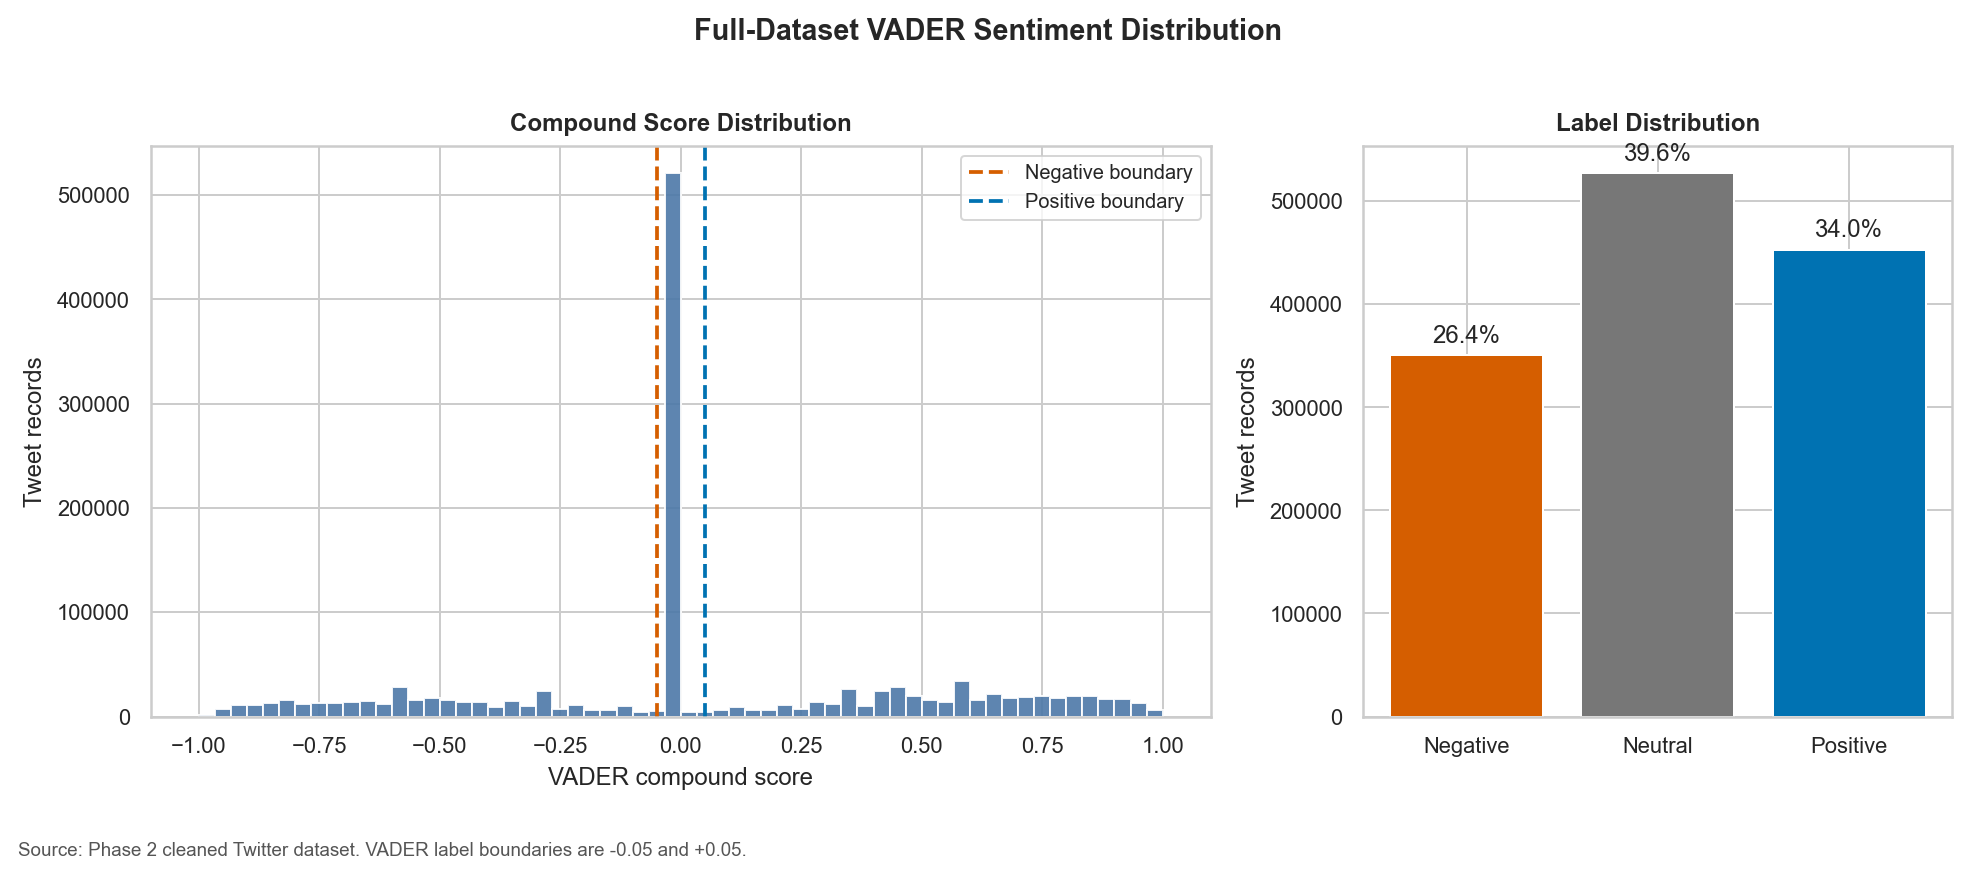

**sentiment_distribution_by_candidate.png**

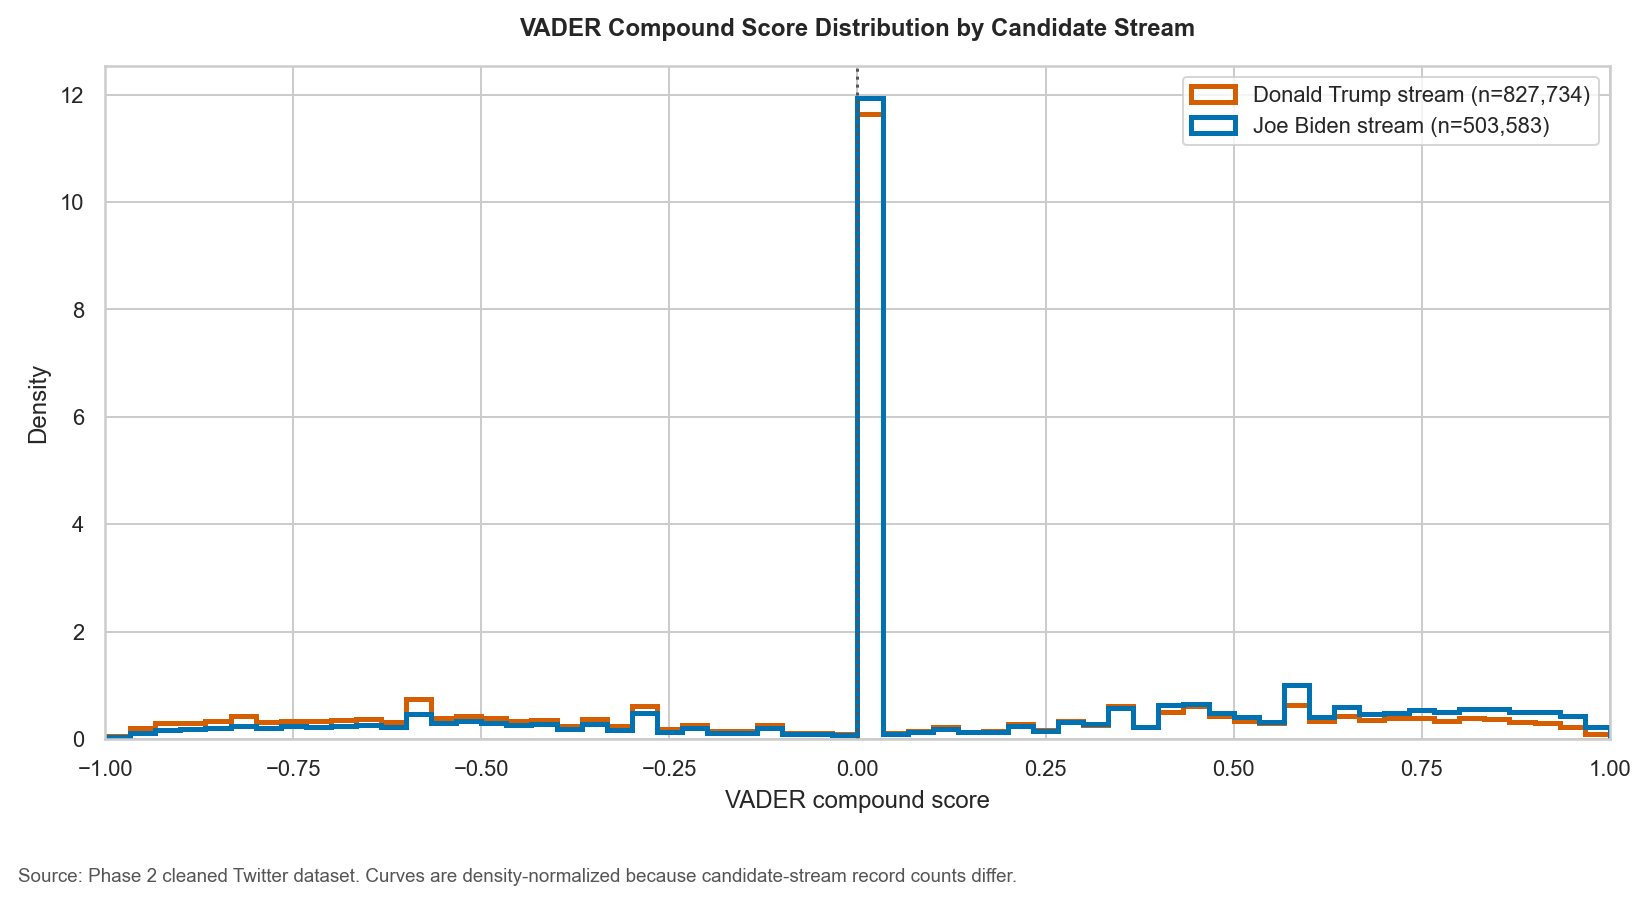

**vader_roberta_score_comparison.png**

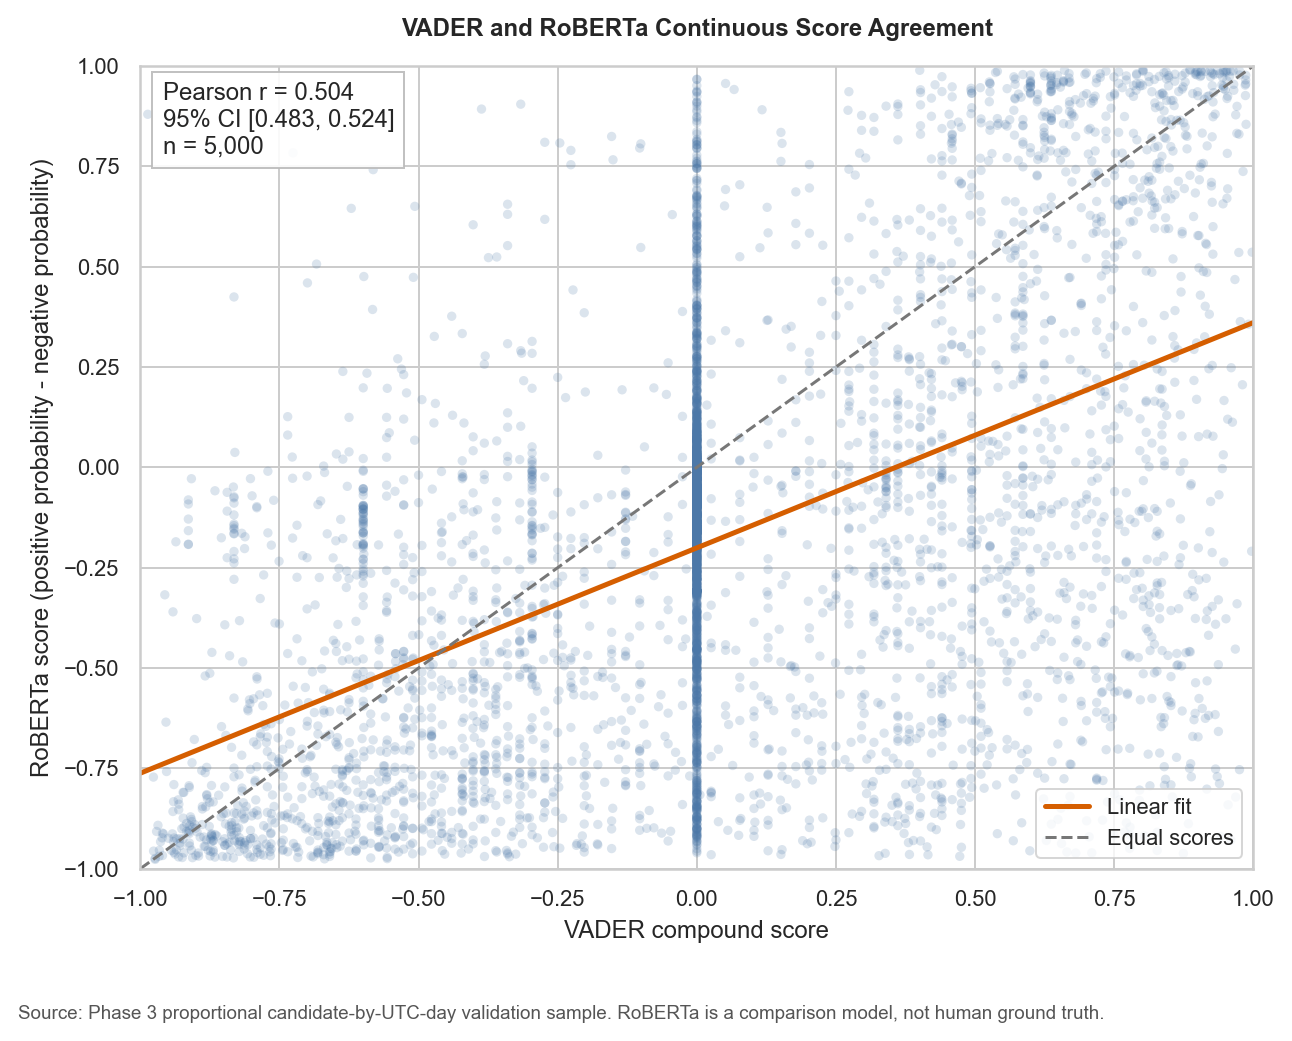

**vader_roberta_confusion_matrix.png**

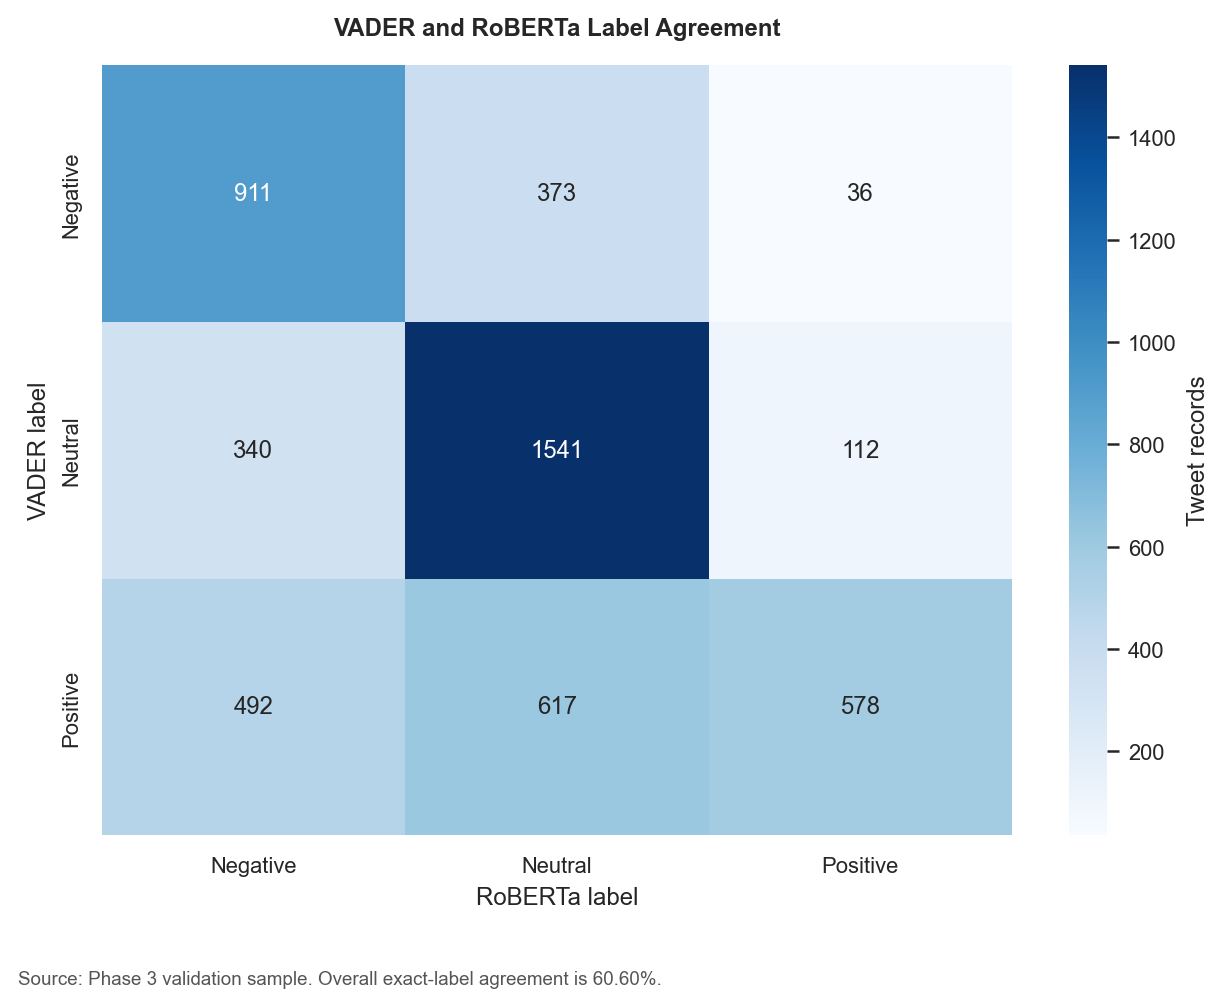

In [11]:
for relative_path in [
    "output/graphs/phase3/vader_sentiment_distribution.png",
    "output/graphs/phase3/sentiment_distribution_by_candidate.png",
    "output/graphs/phase3/vader_roberta_score_comparison.png",
    "output/graphs/phase3/vader_roberta_confusion_matrix.png",
]:
    display(Markdown(f"**{Path(relative_path).name}**"))
    display(Image(filename=str(ROOT / relative_path)))

## Takeaway

Phase 3 uses VADER for scalable full-dataset scoring and Twitter-RoBERTa for a reproducible validation study. The moderate agreement supports using VADER as a practical baseline while preserving a clear limitation: downstream interpretation must account for contextual, multilingual, and sarcasm-related disagreement.